#### Covariance and Pearson Correlation Coefficient
### Quick Overview
- **Covariance** tracks the direction of joint linear movement between two variables (whether they increase together or move in opposite directions).
- **Pearson Correlation ($r$)** rescales covariance to a standardized range between $-1$ and $+1$, quantifying both direction and strength independent of measurement units.
- **Linearity Assumption:** Both metrics strictly evaluate linear relationships and can fail to capture strong non-linear patterns (such as curves or quadratic dependencies).

#### Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Apply clean visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 100

## 1. Sample Covariance (`np.cov`)

* **What it does:** Measures how much two variables change together. A positive value means they move in the same direction; a negative value means they move in opposite directions.
* **Mathematical Notation:**
  $$s_{xy} = \operatorname{Cov}(X, Y) = \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$
  *Where:*
  * $s_{xy}$ (*s sub x y*): Unbiased sample covariance
  * $\bar{x}$ (*x-bar*): Mean of variable $X$
  * $\bar{y}$ (*y-bar*): Mean of variable $Y$
  * $n$ (*n*): Number of observations ($n - 1$ adjusts for sample degrees of freedom)
* **Naive Example:** Study hours $X = [2, 4, 6]$ and Exam Scores $Y = [50, 70, 90]$ ($n = 3$).
  * $\bar{x} = 4$, $\bar{y} = 70$
  * Deviations $X$: $[-2, 0, 2]$, Deviations $Y$: $[-20, 0, 20]$
  * Sum of products: $(-2 \times -20) + (0 \times 0) + (2 \times 20) = 40 + 0 + 40 = 80$
  * Covariance: $\frac{80}{3 - 1} = 40.0$
* **When to use:** When calculating joint variability, portfolio risk matrices, or preparing features for Principal Component Analysis (PCA).

### Sample Covariance: Step-by-Step Numerical Example

Covariance aggregates the multiplied deviations of two variables from their respective means to see if positive deviations in $X$ pair with positive deviations in $Y$.

---

### Step-by-Step Example

#### 1. Input Datasets
$$\text{Study Hours } (X): [2, 4, 6] \quad (n = 3)$$
$$\text{Exam Scores } (Y): [50, 70, 90] \quad (n = 3)$$

#### 2. Calculate Means
$$\bar{x} = \frac{2 + 4 + 6}{3} = 4$$
$$\bar{y} = \frac{50 + 70 + 90}{3} = 70$$

#### 3. Compute Deviations and Product of Deviations
| Student | $x_i$ | $y_i$ | $(x_i - \bar{x})$ | $(y_i - \bar{y})$ | Product $(x_i - \bar{x})(y_i - \bar{y})$ |
|---|---|---|---|---|---|
| 1 | 2 | 50 | $2 - 4 = -2$ | $50 - 70 = -20$ | $(-2) \times (-20) = 40$ |
| 2 | 4 | 70 | $4 - 4 = 0$ | $70 - 70 = 0$ | $0 \times 0 = 0$ |
| 3 | 6 | 90 | $6 - 4 = 2$ | $90 - 70 = 20$ | $2 \times 20 = 40$ |

#### 4. Sum of Products
$$\sum (x_i - \bar{x})(y_i - \bar{y}) = 40 + 0 + 40 = 80$$

#### 5. Calculate Sample Covariance
$$\operatorname{Cov}(X,Y) = \frac{80}{3 - 1} = \frac{80}{2} = 40.0$$

Plain Python Covariance: 40.0
NumPy np.cov Matrix:
[[  4.  40.]
 [ 40. 400.]]
NumPy Covariance Cov(X, Y): 40.0



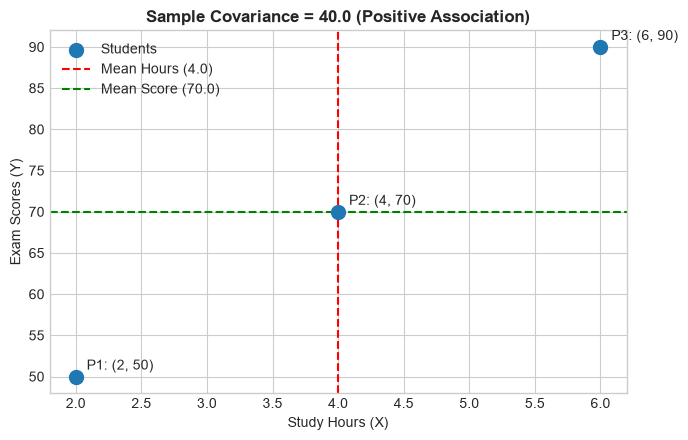

In [4]:
# --- 1. DATA PREPARATION ---
study_hours = np.array([2, 4, 6])
exam_scores = np.array([50, 70, 90])
n = len(study_hours)

# --- 2. PLAIN PYTHON IMPLEMENTATION ---
mean_x = sum(study_hours) / n
mean_y = sum(exam_scores) / n
dev_x = [x - mean_x for x in study_hours]
dev_y = [y - mean_y for y in exam_scores]
prod_dev = [dx * dy for dx, dy in zip(dev_x, dev_y)]
cov_python = sum(prod_dev) / (n - 1)

# --- 3. NUMPY IMPLEMENTATION ---
# rowvar=False treats columns/1D-arrays as variables
cov_matrix_numpy = np.cov(study_hours, exam_scores, rowvar=False, ddof=1) # ddof(delta degrees of freedom)  =1 for sample covariance

cov_numpy = cov_matrix_numpy[0, 1]

print(f"Plain Python Covariance: {cov_python:.1f}")
print(f"NumPy np.cov Matrix:\n{cov_matrix_numpy}")
print(f"NumPy Covariance Cov(X, Y): {cov_numpy:.1f}\n")

# --- 4. VISUAL REPRESENTATION ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(study_hours, exam_scores, color='#1f77b4', s=100, zorder=5, label='Students')
ax.axvline(mean_x, color='red', linestyle='--', label=f'Mean Hours ({mean_x:.1f})')
ax.axhline(mean_y, color='green', linestyle='--', label=f'Mean Score ({mean_y:.1f})')

for i in range(n):
    ax.annotate(f' P{i+1}: ({study_hours[i]}, {exam_scores[i]})',
                (study_hours[i], exam_scores[i]), textcoords="offset points", xytext=(5,5))

ax.set_xlabel('Study Hours (X)')
ax.set_ylabel('Exam Scores (Y)')
ax.set_title(f'Sample Covariance = {cov_numpy:.1f} (Positive Association)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Pearson Correlation Coefficient (`np.corrcoef`)

* **What it does:** Standardizes covariance by scaling it between $-1$ and $+1$ using the standard deviations of both variables. It isolates the strength and direction of linear relationship.
* **Mathematical Notation:**
  $$r_{xy} = \frac{\operatorname{Cov}(X, Y)}{s_x \cdot s_y} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$
  *Where:*
  * $r_{xy}$ (*r sub x y*): Sample Pearson correlation coefficient
  * $s_x$ (*s sub x*): Sample standard deviation of $X$
  * $s_y$ (*s sub y*): Sample standard deviation of $Y$
* **Naive Example:** Using our previous study data ($X=[2, 4, 6]$, $Y=[50, 70, 90]$):
  * $\operatorname{Cov}(X,Y) = 40.0$
  * $s_x = \sqrt{\frac{8}{2}} = 2.0$
  * $s_y = \sqrt{\frac{800}{2}} = 20.0$
  * Pearson Correlation: $r = \frac{40.0}{2.0 \times 20.0} = \frac{40.0}{40.0} = 1.0$ (Perfect Positive Linear Correlation)
* **When to use:** When assessing direct linear relationships, checking feature collinearity, or finding feature-target correlation scale-independently.

Plain Python Pearson r: 1.0000
NumPy np.corrcoef r:   1.0000
Pandas Series corr r:  1.0000

____________________________________________________________
   Hours  Scores
0      2      50
1      4      70
2      6      90
____________________________________________________________
        count  mean   std   min   25%   50%   75%   max
Hours     3.0   4.0   2.0   2.0   3.0   4.0   5.0   6.0
Scores    3.0  70.0  20.0  50.0  60.0  70.0  80.0  90.0


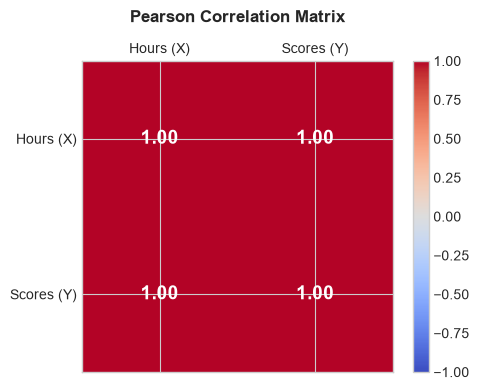

In [15]:
# --- 1. PLAIN PYTHON IMPLEMENTATION ---
var_x = sum((x - mean_x) ** 2 for x in study_hours) / (n - 1)
var_y = sum((y - mean_y) ** 2 for y in exam_scores) / (n - 1)
std_x = math.sqrt(var_x)
std_y = math.sqrt(var_y)

r_python = cov_python / (std_x * std_y)

# --- 2. NUMPY & PANDAS IMPLEMENTATIONS ---
r_numpy_matrix = np.corrcoef(study_hours, exam_scores)
r_numpy = r_numpy_matrix[0, 1]

df = pd.DataFrame({'Hours': study_hours, 'Scores': exam_scores})
r_pandas = df['Hours'].corr(df['Scores'])

print(f"Plain Python Pearson r: {r_python:.4f}")
print(f"NumPy np.corrcoef r:   {r_numpy:.4f}")
print(f"Pandas Series corr r:  {r_pandas:.4f}\n")
print("_" * 60)
print(df)
print("_" * 60)
print(df.describe().T)


# --- 3. VISUAL HEATMAP REPRESENTATION ---
fig, ax = plt.subplots(figsize=(5, 4))
cax = ax.matshow(r_numpy_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{r_numpy_matrix[i, j]:.2f}", ha='center', va='center',
                color='white' if abs(r_numpy_matrix[i, j]) > 0.5 else 'black', fontweight='bold', fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Hours (X)', 'Scores (Y)'])
ax.set_yticklabels(['Hours (X)', 'Scores (Y)'])
ax.set_title('Pearson Correlation Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()